In [2]:
import pandas as pd

df = pd.read_csv("../data/annotation_sample.csv")

print("Total rows:", len(df))
df.head()

Total rows: 200


,id,text,weak_label,manual_label
0,167,the company’s business requires it to use and ...,neutral,neutral
1,249,we make significant investments in products an...,positive_outlook,negative_risk
2,85,the company is also currently subject to antit...,negative_risk,negative_risk
3,169,the company experiences malicious attacks and ...,negative_risk,negative_risk
4,188,"the technology industry, including, in some in...",negative_risk,negative_risk


In [3]:
df["manual_label"].value_counts()

manual_label
negative_risk       161
neutral              29
positive_outlook     10
Name: count, dtype: int64

In [4]:
(df["manual_label"].value_counts(normalize=True) * 100).round(2)

manual_label
negative_risk       80.5
neutral             14.5
positive_outlook     5.0
Name: proportion, dtype: float64

In [5]:
pd.crosstab(
    df["weak_label"],
    df["manual_label"],
    margins=True
)

manual_label,negative_risk,neutral,positive_outlook,All
weak_label,,,,
negative_risk,108,6,0,114
neutral,14,9,4,27
positive_outlook,39,14,6,59
All,161,29,10,200


In [6]:
accuracy = (df["weak_label"] == df["manual_label"]).mean()
print("Weak label accuracy:", round(accuracy, 3))

Weak label accuracy: 0.615


In [7]:
mismatches = df[df["weak_label"] != df["manual_label"]]

print("Total mismatches:", len(mismatches))
mismatches.head(10)

Total mismatches: 77


,id,text,weak_label,manual_label
1,249,we make significant investments in products an...,positive_outlook,negative_risk
12,230,we face intense competition across all markets...,positive_outlook,negative_risk
13,279,we may be required to make available licenses ...,neutral,negative_risk
15,17,the company’s products and services are offere...,positive_outlook,negative_risk
16,99,"conversely, a strengthening of foreign currenc...",positive_outlook,negative_risk
18,247,it is uncertain whether our strategies will at...,positive_outlook,negative_risk
22,156,some third-party digital content providers req...,neutral,negative_risk
23,128,"additionally, the company faces significant co...",positive_outlook,negative_risk
24,204,"conversely, a strengthening of foreign currenc...",positive_outlook,negative_risk
28,170,although malicious attacks perpetrated to gain...,positive_outlook,negative_risk


In [8]:
df["text_length"] = df["text"].str.len()

df["text_length"].describe()

count     200.000000
mean      616.050000
std       466.951309
min        83.000000
25%       237.250000
50%       498.500000
75%       818.250000
max      2192.000000
Name: text_length, dtype: float64

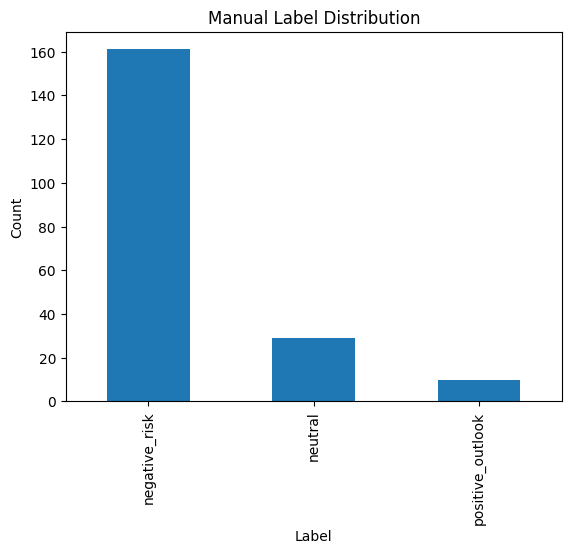

In [9]:
import matplotlib.pyplot as plt

df["manual_label"].value_counts().plot(kind="bar")

plt.title("Manual Label Distribution")
plt.ylabel("Count")
plt.xlabel("Label")
plt.show()

In [10]:
df.groupby("manual_label")["text_length"].mean()

manual_label
negative_risk       695.335404
neutral             331.586207
positive_outlook    164.500000
Name: text_length, dtype: float64

In [11]:
df.to_csv("../data/annotated_training_data.csv", index=False)